In [1]:
import copy # 객체 복사를 위해 사용 크게 얕은 복사와 깊은 복사로 나뉨
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class VGG(nn.Module):
  def __init__(self, features, output_dim):
    super().__init__()

    # 특징 추출기(Feature Extractor): 컨볼루션 층들이 묶인 features를 외부에서 받아옴
    # 보통 vgg11, vgg16 등에 따라 구성이 달라지며, 이미지의 특성을 잡아내는 역할
    self.features = features

    # 입력 이미지의 크기에 상관없이 출력 피처 맵의 크기를 7 x 7로 고정
    # 이를 통해 다양한 해상도의 이미지를 입력으로 받을 수 있다.
    self.avgpool = nn.AdaptiveAvgPool2d(7)

    # 분류기(Classifier): 추출된 특징을 바탕으로 어떤 클래스인지 최종 판단
    self.classifier = nn.Sequential(
        nn.Linear(512*7*7, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, output_dim)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    h = x.view(x.shape[0], -1)
    x = self.classifier(h)
    return x, h

In [3]:
# 8(합성곱층) + 3(풀링층) = 11(전체 계층) = VGG11
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

# 10(합성곱층) + 3(풀링층) = 13(전체 계층) = VGG13
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

# 13(합성곱층) + 3(풀링층) = 16(전체 계층) = VGG16
vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

# 16(합성곱층) + 3(풀링층) = 19(전체 계층) = VGG19
vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']

In [4]:
def get_vgg_layers(config, batch_norm):
  layers = []
  in_channels = 3

  for c in config:
    # assert: 뒤 조건이 True가 아니면 에러 발생
    # isinstance: 주어진 조건이 True인지 판단
    assert c == 'M' or isinstance(c, int)

     # 불러온 값이 'M'이면 최대 풀링(MaxPool2d)을 적용
    if c == 'M':
      layers += [nn.MaxPool2d(kernel_size=2)]

    # 불러온 값이 숫자이면 합성곱(Conv2d) 적용
    else:
      conv2d = nn.Conv2d(in_channels, c, kernel_size=3, padding=1)

      # 배치 정규화(batch normalization)를 적용할지에 대한 코드
      if batch_norm:

        # 배치 정규화가 적용될 경우 배치 정규화 + ReLU 적용
        layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
      else:

        # 배치 정규화가 적용되지 않을 경우 ReLU만 적용
        layers += [conv2d, nn.ReLU(inplace=True)]
      in_channels = c

  return nn.Sequential(*layers) # 네트워크의 모든 계층을 반환

In [5]:
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True)

In [6]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [7]:
OUTPUT_DIM = 2  # 개와 고양이 두 개의 클래스 사용
model = VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [8]:
import torchvision.models as models

# vgg11_bn: VGG11 기본 모델에 배치 정규화가 적용된 모델을 사용하겠다라는 의미
# pretrained: True로 설정하면 사전 훈련된 모델을 사용(미리 학습된 파라미터 값들을 사용)하겠다라는 의미
pretrained_model = models.vgg11_bn(pretrained=True)
print(pretrained_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [9]:
# transforms.Resize: 이미지를 주어진 크기로 재조정
# transforms.RandomRotation: 5도 이하로 이미지를 회전

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [10]:
train_path = '/content/drive/MyDrive/Colab Notebooks/VGGNet/catanddog/train'
test_path = '/content/drive/MyDrive/Colab Notebooks/VGGNet/catanddog/test'

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform = train_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform = test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

In [11]:
VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset) * VALID_RATIO)
n_valid_examples = len(train_dataset) - n_train_examples

train_data, valid_data = data.random_split(train_dataset, [n_train_examples, n_valid_examples])

In [12]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [13]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 476
Number of validation examples: 53
Number of testing examples: 12


In [14]:
BATCH_SIZE = 64
train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_dataset,
                                batch_size=BATCH_SIZE)

In [15]:
optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [16]:
def calculate_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)

  # eq: equal의 약자로 서로 같은지 비교하는 표현식
  # view_as(other): other의 텐서 크기를 사용하겠다는 의미. 즉, view_as(other) == view(other.size())
  # 따라서 y.view_as(top_pred)는 y에 대한 텐서 크기를 top_pred의 텐서 크기로 변경하겠다라는 의미
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float() / y.shape[0]
  return acc

In [17]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.train()
  for (x, y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred, _ = model(x)
    loss = criterion(y_pred, y)
    acc = calculate_accuracy(y_pred, y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc += acc.item()

  return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [18]:
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device)
      y_pred, _ = model(x)
      loss = criterion(y_pred, y)
      acc = calculate_accuracy(y_pred, y)
      epoch_loss += loss.item()
      epoch_acc += acc.item()

  return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [19]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time / 60)
  elapsed_secs = int(elapsed_time - (elapsed_mins * 60))

  return elapsed_mins, elapsed_secs

In [20]:
EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS):

  # time.monotonic(): 시스템이 시작된 이후부터 기록되는 스톱워치(절대 뒤로 흐르지 않음. 두 시점 사이의 간격을 잴 때 사용)
  start_time = time.monotonic()

  # 훈련 데이터셋을 모델에 적용한 결과(오차와 정확도)를 train_loss와 train_acc에 저장
  train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)

  # 검증 데이터셋을 모델에 적용한 결과(오차와 정확도)를 valid_loss와 valid_acc에 저장
  valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

  # valid_loss가 가장 작은 값을 구하고 그 상태의 모델을 VGG-model.pt 이름으로 저장
  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/VGGNet/VGG-model.pt')

  end_time = time.monotonic()

  # 모델 훈련에 대한 시작과 종료 시간을 저장
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
  print(f'\t Valid. Loss: {valid_loss:.3f} | Valid. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 8m 38s
	Train Loss: 0.699 | Train Acc: 51.09%
	 Valid. Loss: 0.694 | Valid. Acc: 47.17%
Epoch: 02 | Epoch Time: 8m 44s
	Train Loss: 0.702 | Train Acc: 48.97%
	 Valid. Loss: 0.693 | Valid. Acc: 47.17%
Epoch: 03 | Epoch Time: 9m 36s
	Train Loss: 0.703 | Train Acc: 46.76%
	 Valid. Loss: 0.692 | Valid. Acc: 58.49%
Epoch: 04 | Epoch Time: 10m 0s
	Train Loss: 0.703 | Train Acc: 49.72%
	 Valid. Loss: 0.690 | Valid. Acc: 66.04%
Epoch: 05 | Epoch Time: 9m 5s
	Train Loss: 0.699 | Train Acc: 49.47%
	 Valid. Loss: 0.685 | Valid. Acc: 64.15%


In [20]:
# torch.load: 파일로 저장된 가중치를 읽어옴
# model.load_state_dict: 읽어온 가중치를 현재 모델 뼈대(Layer 구조)에 그대로 이식함
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/VGGNet/VGG-model.pt'))

# 학습 때 쓰지 않은 완전히 새로운 데이터(test_iterator)를 사용하여 모델의 일반화 성능 확인
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

In [23]:
def get_predictions(model, iterator):
  model.eval()
  images = []
  labels = []
  probs = []

  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred, _ = model(x)

      # dim=1: 클래스 방향(가로)으로 확률의 합이 1이 되게 함
      y_prob = F.softmax(y_pred, dim=1)

      # argmax: 배열에서 가장 큰 값의 인덱스를 찾을 때 사용
      # keepdim: keepdim=True의 경우 출력 텐서를 입력과 동일한 크기로 유지하겠다는 의미
      top_pred = y_prob.argmax(1, keepdim=True)

      # 수집한 데이터를 CPU 메모리로 옮겨서 리스트에 추가
      # .cpu를 해주지 않으면 GPU 메모리가 부족해질 수 있음
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())

  # dim=0: 데이터 개수 방향으로 쌓으라는 의미
  # torch.cat: 텐서를 연결할 때 사용
  images = torch.cat(images, dim=0)
  labels = torch.cat(labels, dim=0)
  probs = torch.cat(probs, dim=0)

  return images, labels, probs

In [24]:
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)

# 실제 정답과 예측한 값이 일치한지 비교
corrects = torch.eq(labels, pred_labels)
correct_examples = []

# zip(): 여러 개의 리스트를 하나로 묶어서 동시에 하나씩 꺼내쓰게 해주는 도구
for image, label, prob, correct in zip(images, labels, probs, corrects):
  if correct:
    correct_examples.append((image, label, prob))

# reverse=True: 내림차순
# key=lambda x: 모델이 예측한 확률 중 가장 큰 값을 기준으로 정렬
# x[2]는 prob(확률분포)이며, 여기서 torch.max().values를 통해 최고 확률값을 추출함
correct_examples.sort(reverse=True, key=lambda x: torch.max(x[2], dim=0).values)

In [25]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()

  # image.clamp: 주어진 최소(min), 최대(max)의 범주에 이미지가 위치하도록 한다.
  image.clamp_(min=image_min, max=image_max)
  image.add_(-image_min).div_(image_max-image_min+1e-5)

  return image

In [26]:
import matplotlib.pyplot as plt

def plot_most_correct(correct, classes, n_images, normalize=True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize=(25, 20))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs = correct[i]

    # permute: 텐서의 차원 순서를 맞바꾸는 기능
    # 이미지 차원 변경: 파이토치(C, H, W) -> 맷플롯립(H, W, C) 순서로 바꿈
    image = image.permute(1, 2, 0)
    true_prob = probs[true_label]
    correct_prob, correct_label = torch.max(probs, dim=0)
    true_class = classes[true_label]
    correct_class = classes[correct_label]

    # 정규화 해제(학습을 위해 변경된 색상을 다시 원래대로 되돌림)
    if normalize:
      image = normalize_image(image)

    ax.imshow(image.cpu().numpy())
    ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' \
                 f'pred label: {correct_class} ({correct_prob:.3f})')
    ax.axis('off')

  fig.subplots_adjust(hspace=0.4)

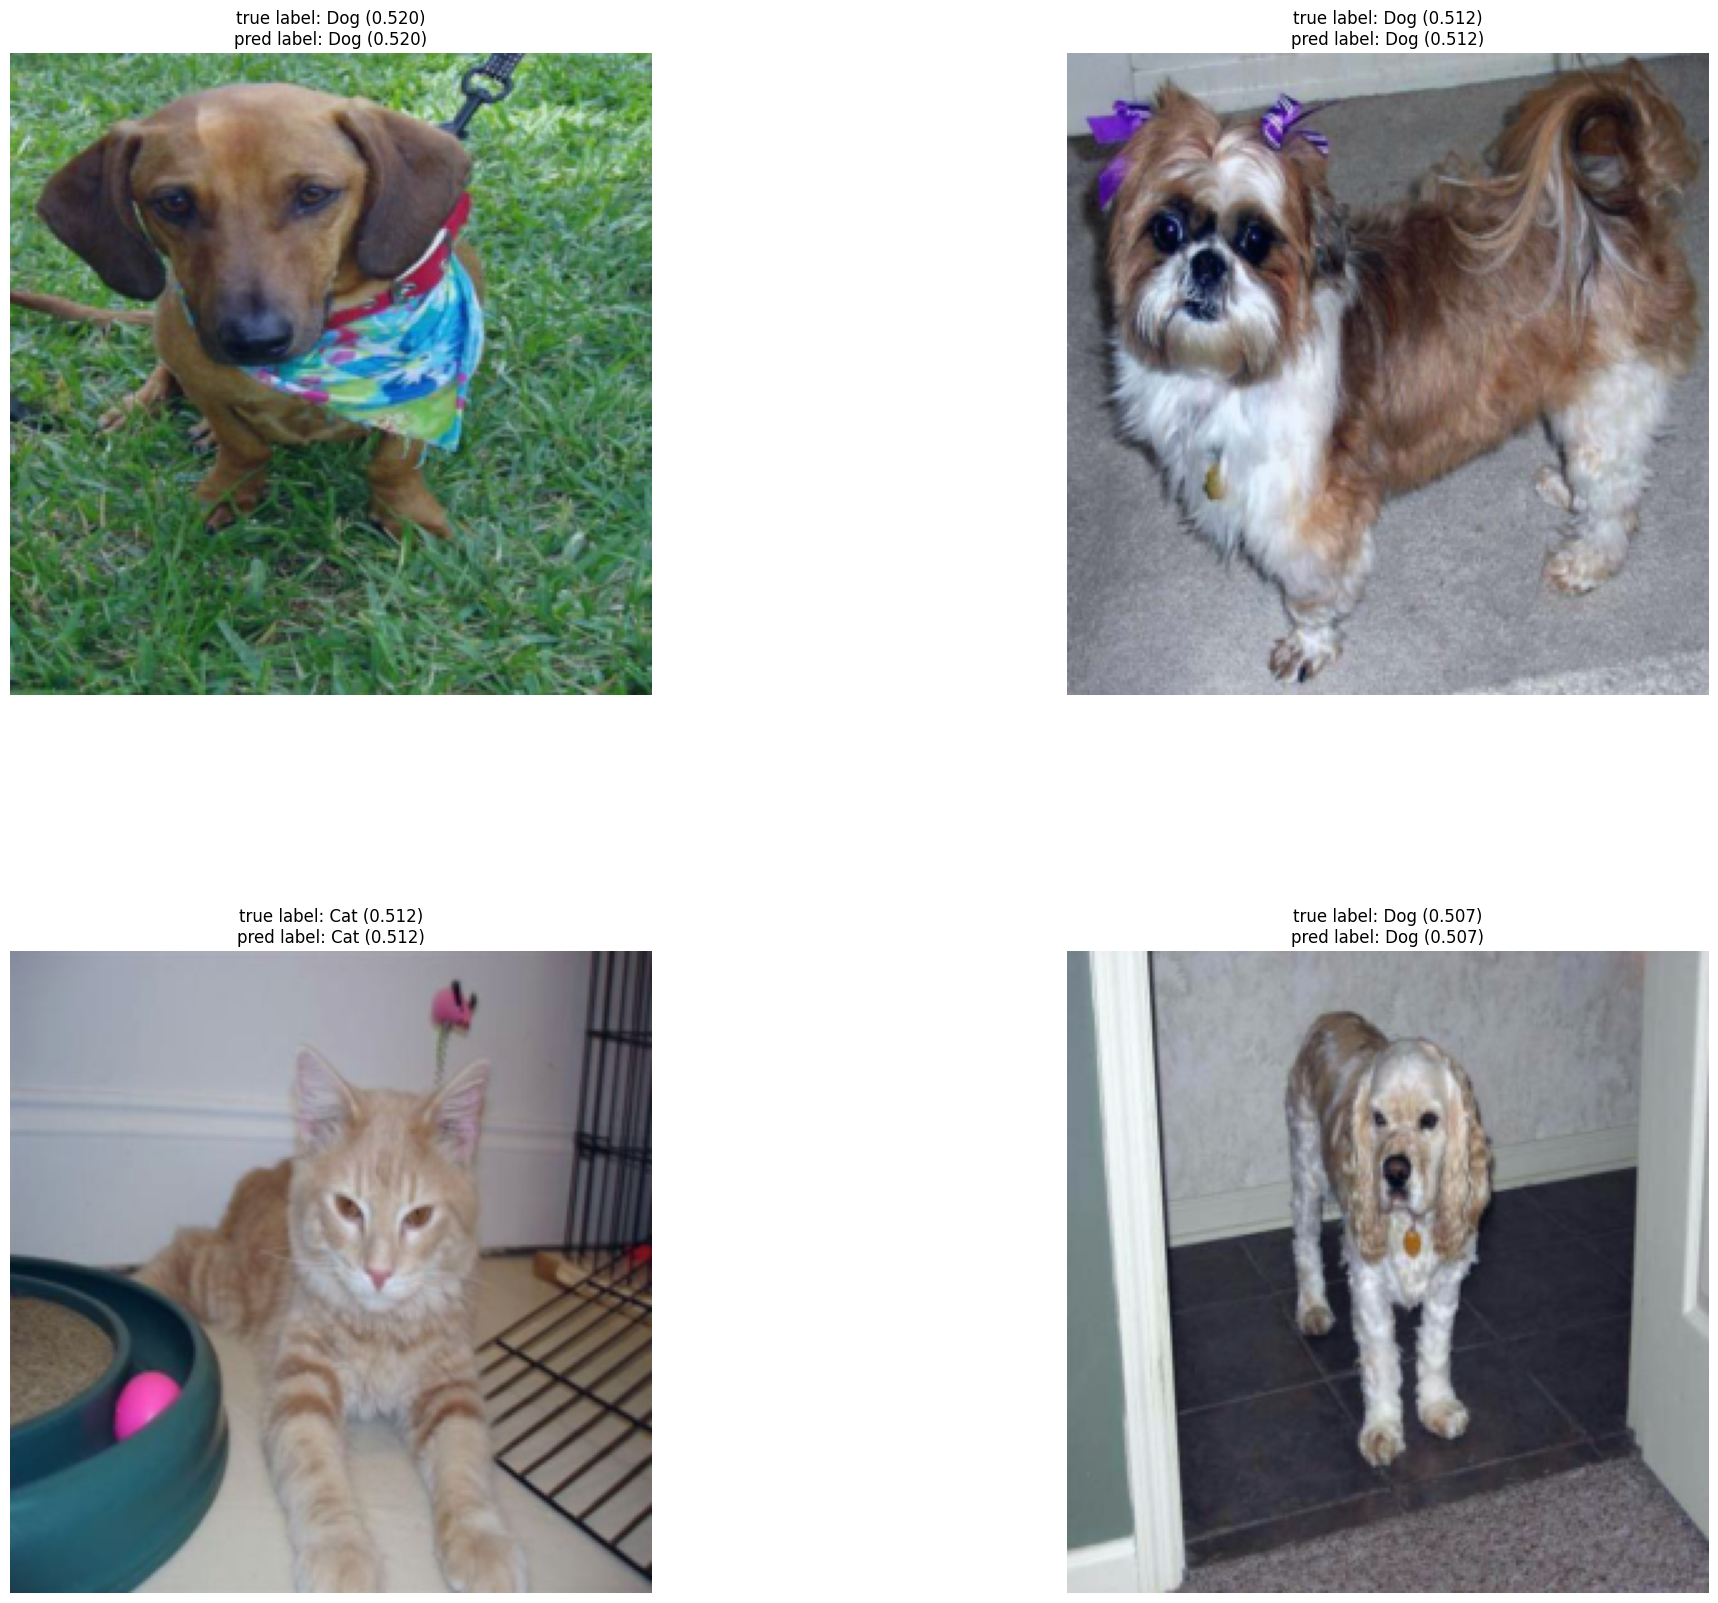

In [27]:
classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)